# ftir_21 — every calibration run twice: Calibration app vs site-held-out protocol

## tl;dr

Every calibration setup run end-to-end **twice** — once under the **Calibration app**
protocol (10-fold interleaved CV, k = first within 5% of the minimum, model fitted on all
cohort filters) and once under the **site-held-out** protocol (site-grouped 5-fold CV,
first-major-minimum, fitted on the training side of a site-disjoint 80/20 split) — with the same cohorts, the
same spectra and the same PLS math. The two modes are switchable in
`scripts/calibration_modes.py`, named for what they do rather than for who runs them.
**Provenance first**: the `site_heldout` mode reproduces the
committed ftir_11/ftir_13 calibrations exactly (k = 6 / 5, Addis slope and intercept to
< 1e-6), so the comparison is a like-for-like re-run and not a re-derivation.
**The protocol moves the Addis answer, and by more than the MAC fork does.** On the
lowest-OC/EC cohort the Calibration app protocol turns the site-held-out
**1.59x − 3.22 (RMSE 1.16)** into **2.15x − 4.59 (RMSE 2.03)** — the same 800 filters, made to look a full 1.4 µg/m³ worse
in intercept purely by how k was chosen. Biomass-smoke swings hardest (**2.43x − 6.35**
app-protocol, **0.50x − 0.99** site-held-out at k = 4), and the whole IMPROVE network goes
1.95x − 4.05 → 1.65x − 3.44. The one setup the protocol barely touches is
**lowest-OC/EC + AIRSpec**: −1.65 vs −1.62, slope 0.96 vs 0.86 — a calibration whose Addis
answer does not depend on who processed it, which is exactly the robustness the deck
should claim for it. **The held-out TOR test, which only the site-held-out protocol produces,
also re-sorts the field**: lowest-OC/EC + AIRSpec (R² 0.90, slope 1.01) and lowest-OC/EC
(0.91 / 0.87) pass cleanly, the IMPROVE network passes on slope (0.70 / 0.99), and
**Ethiopia-shaped smoke collapses (R² 0.00, slope −2.20)** — a setup still carried in the
matrix at intercept −3.69 turns out to have no held-out skill at all once sites are
disjoint.

## Context & Methods

ftir_20 showed that the AQRC **FTIR Calibration** Shiny app and this project pick the
number of PLS components by different rules on differently-drawn CV folds. This notebook
takes the obvious next step: run **every** calibration setup all the way through to the
Addis numbers under **both protocols**, so each row of the deck's
`calibration_setup_matrix` is calibrated twice — once under each protocol — on the same
filters, the same spectra and the same PLS math.

The two modes live in `scripts/calibration_modes.py` so any future notebook can switch
between them:

| | `app` (Calibration app) | `site_heldout` (Site-held-out) |
|---|---|---|
| CV folds | 10-fold **interleaved**, no site grouping | 5-fold **site-grouped** |
| component rule | first k within 5% of the curve minimum | first major minimum (local min within 1 SE) |
| final fit | **all** cohort filters | training part of a site-disjoint 80/20 split (seed 20260717) |
| held-out TOR test | none, by construction | yes, on the disjoint 20% |

`app` reproduces `pls::plsr(ncomp = 80, validation = "CV", segments = 10,
segment.type = "interleaved")` plus fitting the shipped model on everything, which is
what the Calibration app does. `site_heldout` is the protocol locked in ftir_10/ftir_11;
both are named for what they do rather than for who runs them.

**Addis is external to both training sets**, so the Addis slope/intercept comparison is
apples-to-apples; the held-out TOR test exists only for `site_heldout`, and that is
a property of the protocols rather than a gap in this notebook.

Two labelling points carried over from ftir_20. The matrix's "Deployed SPARTAN" row is
shown as what it is on the training side — the **entire IMPROVE network**, every eligible
lot-248/251 filter with no selection (13,010 filters, 158 sites). The deployed model is a
network calibration trained on IMPROVE; the only SPARTAN spectra in this project are
ETAD's and they are the *evaluation* set, never training data. And the locked
spectral-analog cohort is the top **500** candidates, not the matrix's superseded "400".

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

from phase3_common import (
    PATHS, PHASE2_TABLES, load_addis_evaluation, load_pool_metadata, load_tor_loadings,
)
from calibration_modes import MODES, MODE_SHORT, fit_calibration, addis_metrics

TABLE_DIR = Path('output/tables/ftir21')
PLOT_DIR = Path('output/plots/ftir21')
DECK_DIR = Path('output/plots/deck')
for directory in (TABLE_DIR, PLOT_DIR, DECK_DIR):
    directory.mkdir(parents=True, exist_ok=True)

INK, MUTED = '#22252A', '#6B6E75'
APP_COLOUR, HELDOUT_COLOUR = '#B23327', '#2C6E9E'   # validated pair (CVD ΔE 18.5)
MODE_COLOUR = {'app': APP_COLOUR, 'site_heldout': HELDOUT_COLOUR}

## Data

### 1. Addis evaluation set, IMPROVE pool, and the six cohort membership lists

Identical construction to ftir_20 so the cohorts are the same training sets.

In [2]:
etad_eval, X_addis_raw, wavenumbers = load_addis_evaluation()
wcols = list(etad_eval.attrs['wcols'])
fabs = etad_eval['Fabs'].to_numpy(float)
volume = etad_eval['SampleVolume_m3'].to_numpy(float)
fixed_mask = etad_eval['EC_deployed_ugm3'].notna().to_numpy()
print(f'Addis evaluation: {len(etad_eval)} filters with HIPS, '
      f'{int(fixed_mask.sum())} in the fixed phase-2 cohort')

pool_raw = pd.read_csv(PATHS.ftir_dir / 'local_db/spectra_248_251.csv',
                       usecols=['AnalysisId'] + wcols,
                       dtype={c: np.float32 for c in wcols})
pool_raw = pool_raw[~pool_raw['AnalysisId'].duplicated()].set_index('AnalysisId')
pool_raw.index = pool_raw.index.astype(int)

pool = (load_pool_metadata()
        .merge(load_tor_loadings(), on=['Site', 'date'], how='left', validate='many_to_one')
        .query('TOR_EC_loading_ug > 0')
        .drop_duplicates('FilterId'))
pool['AnalysisId'] = pool['AnalysisId'].astype(int)
pool = pool[pool['AnalysisId'].isin(pool_raw.index)].drop_duplicates('AnalysisId')
pool = pool.set_index('AnalysisId')[['Site', 'TOR_EC_loading_ug']]

smoke = pd.read_csv(PHASE2_TABLES / 'pls_calibration_phase2/smoke_cohort_spectral_selection.csv')
analog = pd.read_csv(PHASE2_TABLES / 'pls_calibration_phase2/locked_analog_train_test_split.csv')
ocec = pd.read_csv('output/tables/ftir11/lowest_ocec_800_cohort.csv')

MEMBERSHIP = {
    'Entire IMPROVE network\n(13,010, no selection)': pool.index.to_numpy(),
    'Biomass-smoke (906)': smoke['AnalysisId'].to_numpy(int),
    'Ethiopia-shaped smoke (300)':
        smoke.loc[smoke['selected_Ethiopia_shaped_smoke'], 'AnalysisId'].to_numpy(int),
    'Spectral analogs (locked 500)': analog['AnalysisId'].to_numpy(int),
    'Lowest-OC/EC (800)': ocec['AnalysisId'].to_numpy(int),
    'Lowest-OC/EC + AIRSpec (800)': ocec['AnalysisId'].to_numpy(int),
}
AIRSPEC_COHORT = 'Lowest-OC/EC + AIRSpec (800)'

# AIRSpec-corrected spectra for the one cohort that uses them — pool side and Addis side,
# both from ftir_13's df1 = 6 run so training and evaluation stay in the same space.
corrected_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
corrected_row = {int(a): i for i, a in enumerate(corrected_npz['analysis_id'].astype(int))}
etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
etad_corr = pd.DataFrame(etad_npz['corrected'].astype(float))
etad_corr['MediaId'] = etad_npz['media_id'].astype(int)
X_addis_corrected = (etad_corr.groupby('MediaId').mean()
                     .loc[etad_eval['MediaId'].astype(int)].to_numpy(float))

cohort_ids = {}
for name, ids in MEMBERSHIP.items():
    keep = [i for i in dict.fromkeys(int(v) for v in ids)
            if i in pool.index and (name != AIRSPEC_COHORT or i in corrected_row)]
    cohort_ids[name] = np.array(keep, dtype=int)
    print(f'{name.replace(chr(10), " "):40s} n = {len(keep):5d}  '
          f'sites = {pool.loc[keep, "Site"].nunique():3d}')

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08
Addis evaluation: 239 filters with HIPS, 190 in the fixed phase-2 cohort


Entire IMPROVE network (13,010, no selection) n = 13010  sites = 158
Biomass-smoke (906)                      n =   906  sites = 140
Ethiopia-shaped smoke (300)              n =   300  sites = 111
Spectral analogs (locked 500)            n =   500  sites = 127
Lowest-OC/EC (800)                       n =   800  sites = 126
Lowest-OC/EC + AIRSpec (800)             n =   800  sites = 126


## Results

### 2. Fit every cohort under both protocols

Twelve end-to-end calibrations. The IMPROVE-network cohort dominates the runtime.

In [3]:
fits, metric_rows, summary_rows = {}, [], []
for name, ids in cohort_ids.items():
    if name == AIRSPEC_COHORT:
        X = corrected_npz['corrected'][[corrected_row[i] for i in ids]].astype(float)
        X_addis, spectra_label = X_addis_corrected, 'AIRSpec df1=6 baselined'
    else:
        X = pool_raw.loc[ids, wcols].to_numpy(float)
        X_addis, spectra_label = X_addis_raw, 'as-measured'
    y = pool.loc[ids, 'TOR_EC_loading_ug'].to_numpy(float)
    sites = pool.loc[ids, 'Site'].to_numpy()

    for mode in MODES:
        fit = fit_calibration(mode, name, X, y, sites, X_addis, volume)
        fits[(name, mode)] = fit
        for evaluation_set, mask in (('fixed phase-2 cohort', fixed_mask),
                                     ('available pairs', np.ones(len(etad_eval), bool))):
            metric_rows += addis_metrics(fit, fabs, mask, cohort_label=evaluation_set)
        summary_rows.append({
            'cohort': name.replace('\n', ' '), 'mode': mode, 'spectra': spectra_label,
            'k': fit.k, 'n_train': fit.n_train, 'n_train_sites': fit.n_train_sites,
            'rmsecv_floor_ug': fit.rmsecv_floor,
            'pct_rmsecv_floor': fit.pct_rmsecv_floor,
            'heldout_TOR_R2': fit.heldout['R2'] if fit.heldout else np.nan,
            'heldout_TOR_slope': fit.heldout['slope'] if fit.heldout else np.nan,
            'heldout_TOR_RMSE': fit.heldout['RMSE'] if fit.heldout else np.nan,
        })
    print(f'{name.replace(chr(10), " "):40s} '
          f"k: Calibration app {fits[(name, 'app')].k:2d} | "
          f"site-held-out {fits[(name, 'site_heldout')].k:2d}")

metrics = pd.DataFrame(metric_rows)
metrics['cohort'] = metrics['cohort'].str.replace('\n', ' ', regex=False)
summary = pd.DataFrame(summary_rows)
metrics.to_csv(TABLE_DIR / 'addis_metrics_by_mode.csv', index=False)
summary.to_csv(TABLE_DIR / 'calibration_summary_by_mode.csv', index=False)
pd.DataFrame({'MediaId': etad_eval['MediaId'], 'Fabs': fabs, **{
    f'{name.replace(chr(10), " ")} [{mode}]': fit.addis_ugm3
    for (name, mode), fit in fits.items()}}).to_csv(
        TABLE_DIR / 'addis_predictions_by_mode.csv', index=False)

Entire IMPROVE network (13,010, no selection) k: Calibration app 27 | site-held-out 15


Biomass-smoke (906)                      k: Calibration app 19 | site-held-out  4


Ethiopia-shaped smoke (300)              k: Calibration app 17 | site-held-out 10


Spectral analogs (locked 500)            k: Calibration app  9 | site-held-out  4


Lowest-OC/EC (800)                       k: Calibration app 17 | site-held-out  6


Lowest-OC/EC + AIRSpec (800)             k: Calibration app 19 | site-held-out  5


### 2b. Provenance check: `site_heldout` mode must reproduce the locked calibrations

The `site_heldout` mode is a re-implementation of the ftir_11/ftir_13 protocol, so running the
lowest-OC/EC cohort through it has to land on the committed numbers exactly — same k,
same Addis slope and intercept. If this assertion ever fails, the mode has drifted from
the locked protocol and nothing below it is trustworthy.

In [4]:
committed = pd.read_csv('output/tables/ftir13/addis_metrics_corrected.csv').query('MAC_m2_g == 10')
checks = []
for key, cohort, expected_k in (
        ('lowest-OCEC 800 (raw spectra)', 'Lowest-OC/EC (800)', 6),
        ('lowest-OCEC 800, AIRSpec df1=6', 'Lowest-OC/EC + AIRSpec (800)', 5)):
    reference = committed[committed['model'].str.startswith(key)].iloc[0]
    got = metrics[(metrics['cohort'] == cohort) & (metrics['mode'] == 'site_heldout')
                  & (metrics['MAC_m2_g'] == 10)
                  & (metrics['evaluation_set'] == 'fixed phase-2 cohort')].iloc[0]
    assert int(got['k']) == expected_k, (cohort, got['k'], expected_k)
    for column in ('slope', 'intercept'):
        assert abs(float(got[column]) - float(reference[column])) < 1e-6, (cohort, column)
    checks.append({'cohort': cohort, 'k': int(got['k']),
                   'committed_slope': float(reference['slope']),
                   'ftir21_slope': float(got['slope']),
                   'committed_intercept': float(reference['intercept']),
                   'ftir21_intercept': float(got['intercept'])})
print('site_heldout mode reproduces the locked ftir_11 / ftir_13 calibrations exactly')
display(pd.DataFrame(checks))

site_heldout mode reproduces the locked ftir_11 / ftir_13 calibrations exactly


,cohort,k,committed_slope,ftir21_slope,committed_intercept,ftir21_intercept
0,Lowest-OC/EC (800),6,1.585381,1.585381,-3.221502,-3.221502
1,Lowest-OC/EC + AIRSpec (800),5,0.857004,0.857004,-1.615099,-1.615099


### 3. The headline table: what the protocol costs at Addis

Fixed 190-filter cohort at MAC = 10 — the same rows the deck's intercept column quotes.

In [5]:
headline = (metrics[(metrics['MAC_m2_g'] == 10)
                    & (metrics['evaluation_set'] == 'fixed phase-2 cohort')]
            .pivot(index='cohort', columns='mode',
                   values=['k', 'slope', 'intercept', 'R2', 'RMSE']))
headline = headline.reindex([n.replace('\n', ' ') for n in cohort_ids])
headline.to_csv(TABLE_DIR / 'headline_by_mode.csv')
display(headline.round(2))

k              slope  \
mode                                            app site_heldout   app   
cohort                                                                   
Entire IMPROVE network (13,010, no selection)  27.0         15.0  1.95   
Biomass-smoke (906)                            19.0          4.0  2.43   
Ethiopia-shaped smoke (300)                    17.0         10.0  1.65   
Spectral analogs (locked 500)                   9.0          4.0  2.78   
Lowest-OC/EC (800)                             17.0          6.0  2.15   
Lowest-OC/EC + AIRSpec (800)                   19.0          5.0  0.96   

                                                           intercept  \
mode                                          site_heldout       app   
cohort                                                                 
Entire IMPROVE network (13,010, no selection)         1.65     -4.05   
Biomass-smoke (906)                                   0.50     -6.35   
Ethiopia-shaped smoke (300)                           1.59     -3.44   
Spectral analogs (locked 500)                         2.48     -6.12   
Lowest-OC/EC (800)                                    1.59     -4.59   
Lowest-OC/EC + AIRSpec (800)                          0.86     -1.65   

                                                              R2               \
mode                                          site_heldout   app site_heldout   
cohort                                                                          
Entire IMPROVE network (13,010, no selection)        -3.44  0.77         0.75   
Biomass-smoke (906)                                  -0.99  0.69         0.62   
Ethiopia-shaped smoke (300)                          -3.67  0.74         0.75   
Spectral analogs (locked 500)                        -6.35  0.76         0.75   
Lowest-OC/EC (800)                                   -3.22  0.76         0.77   
Lowest-OC/EC + AIRSpec (800)                         -1.62  0.70         0.66   

                                               RMSE               
mode                                            app site_heldout  
cohort                                                            
Entire IMPROVE network (13,010, no selection)  1.63         1.25  
Biomass-smoke (906)                            2.37         3.49  
Ethiopia-shaped smoke (300)                    1.28         1.41  
Spectral analogs (locked 500)                  3.61         2.37  
Lowest-OC/EC (800)                             2.03         1.16  
Lowest-OC/EC + AIRSpec (800)                   1.96         2.41

### 4. Both protocols on the same Addis axes

One panel per calibration setup, fixed cohort, MAC = 10. Red is the Calibration app
protocol, blue is the site-held-out protocol; the grey dashed line is 1:1. Same filters and same HIPS values in every panel —
only the training protocol differs between the two clouds.

Each panel is drawn on its **own square axes** (equal x and y range, sized to that
panel's data) rather than one shared range. Shared limits would clip the high-slope
panels — the analog and smoke models predict up to ~17 µg/m³ against a HIPS axis that
stops at 8.7 — while squashing the AIRSpec panel into a corner. Square axes keep 1:1 at
45° everywhere, so over- and under-prediction still read correctly; just don't compare
panel *extents* to each other.

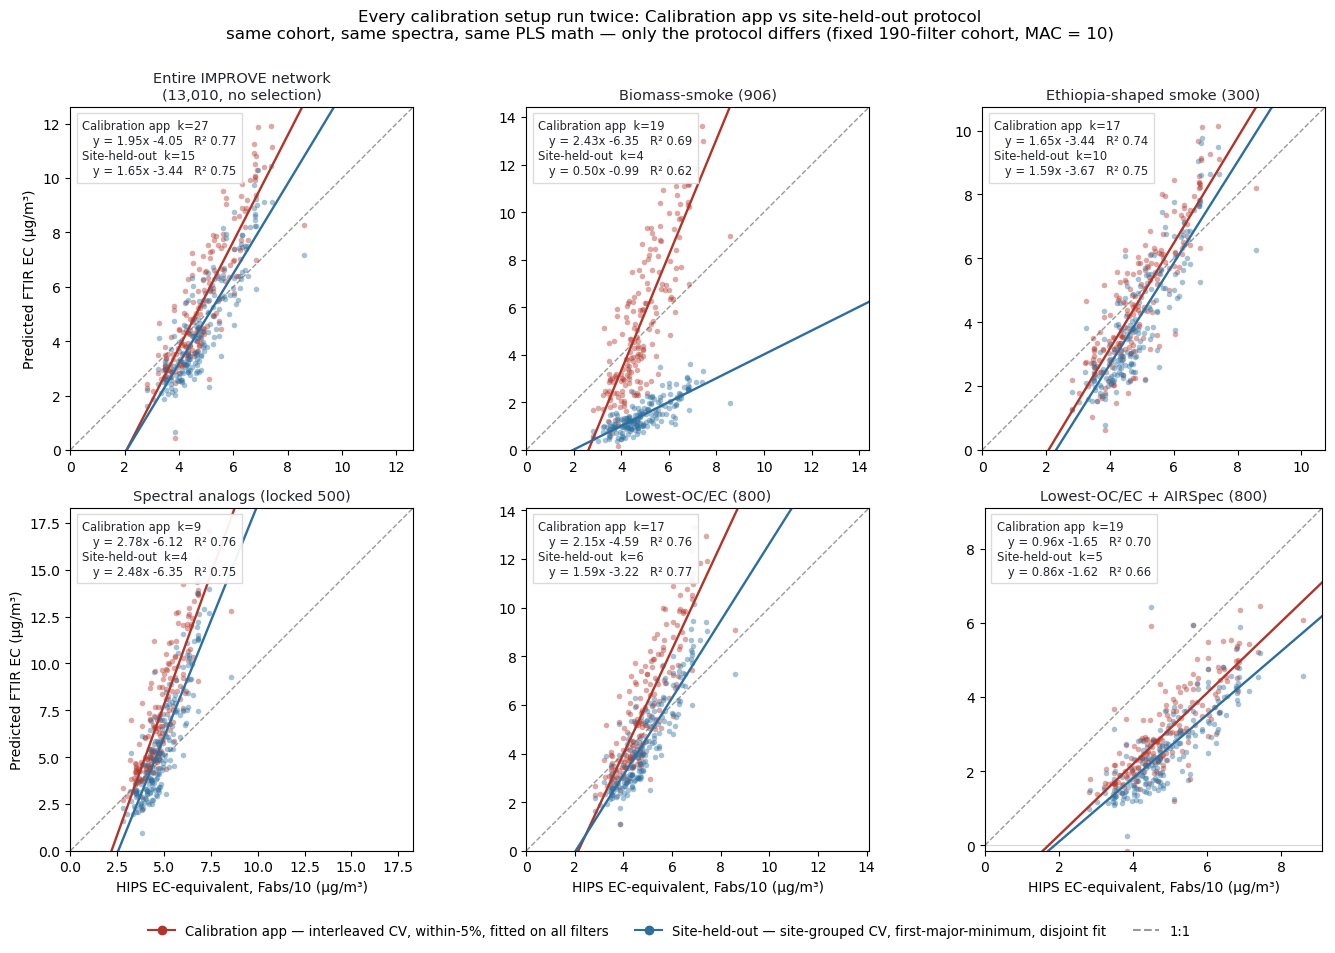

In [6]:
PANELS = list(cohort_ids)
x = fabs / 10

# Each panel gets its own SQUARE limits: identical x and y range, sized to that panel's
# own data. Shared limits would either clip the high-slope panels (predictions reach
# ~17 µg/m³ while HIPS tops out at 8.7) or squash the AIRSpec panel to nothing. Square
# axes keep the 1:1 line at 45° in every panel, so the eye can still read over/under
# prediction — but the ranges differ between panels, so compare shapes, not extents.
fig, axes = plt.subplots(2, 3, figsize=(14.2, 9.0))
for ax, name in zip(axes.flat, PANELS):
    panel_predictions = np.concatenate(
        [fits[(name, m)].addis_ugm3[fixed_mask] for m in MODES])
    hi = float(max(np.nanmax(x[fixed_mask]), np.nanmax(panel_predictions))) * 1.06
    lo = min(0.0, float(np.nanmin(panel_predictions))) * 1.05
    ax.plot([0, hi], [0, hi], '--', color='0.6', lw=1, zorder=1)
    ax.axhline(0, color='0.85', lw=.8, zorder=0)
    text = []
    for mode in MODES:
        fit = fits[(name, mode)]
        prediction = fit.addis_ugm3[fixed_mask]
        row = metrics[(metrics['cohort'] == name.replace('\n', ' '))
                      & (metrics['mode'] == mode) & (metrics['MAC_m2_g'] == 10)
                      & (metrics['evaluation_set'] == 'fixed phase-2 cohort')].iloc[0]
        ax.scatter(x[fixed_mask], prediction, s=16, alpha=.42,
                   color=MODE_COLOUR[mode], lw=0)
        ax.plot([0, hi], [row['intercept'], row['slope'] * hi + row['intercept']],
                color=MODE_COLOUR[mode], lw=1.7)
        text.append(f'{MODE_SHORT[mode]}  k={fit.k}\n'
                    f'   y = {row["slope"]:.2f}x {row["intercept"]:+.2f}   '
                    f'R² {row["R2"]:.2f}')
    ax.set_title(name, fontsize=10.5, color=INK)
    ax.text(.035, .965, '\n'.join(text), transform=ax.transAxes, va='top', fontsize=8.3,
            color=INK, bbox=dict(facecolor='white', edgecolor='0.85', alpha=.93))
    ax.set_xlim(0, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect('equal', adjustable='box')
for ax in axes[1]:
    ax.set_xlabel('HIPS EC-equivalent, Fabs/10 (µg/m³)')
for ax in axes[:, 0]:
    ax.set_ylabel('Predicted FTIR EC (µg/m³)')
fig.legend(handles=[
    Line2D([], [], color=APP_COLOUR, marker='o', ls='-', markersize=6,
           label='Calibration app — interleaved CV, within-5%, fitted on all filters'),
    Line2D([], [], color=HELDOUT_COLOUR, marker='o', ls='-', markersize=6,
           label='Site-held-out — site-grouped CV, first-major-minimum, disjoint fit'),
    Line2D([], [], color='0.6', ls='--', label='1:1'),
], loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(.5, -.045), fontsize=9.5)
fig.suptitle('Every calibration setup run twice: Calibration app vs site-held-out protocol\n'
             'same cohort, same spectra, same PLS math — only the protocol differs '
             '(fixed 190-filter cohort, MAC = 10)', y=1.0)
fig.tight_layout()
for target in (PLOT_DIR / 'both_modes_crossplots.png',
               DECK_DIR / 'both_modes_crossplots.png'):
    fig.savefig(target, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

### 5. The deck strip: intercept and slope, protocol by protocol

The matrix's intercept column, recomputed under both protocols, with the slope beside it.
ftir_19 established that the MAC choice cannot move an intercept — the protocol can.

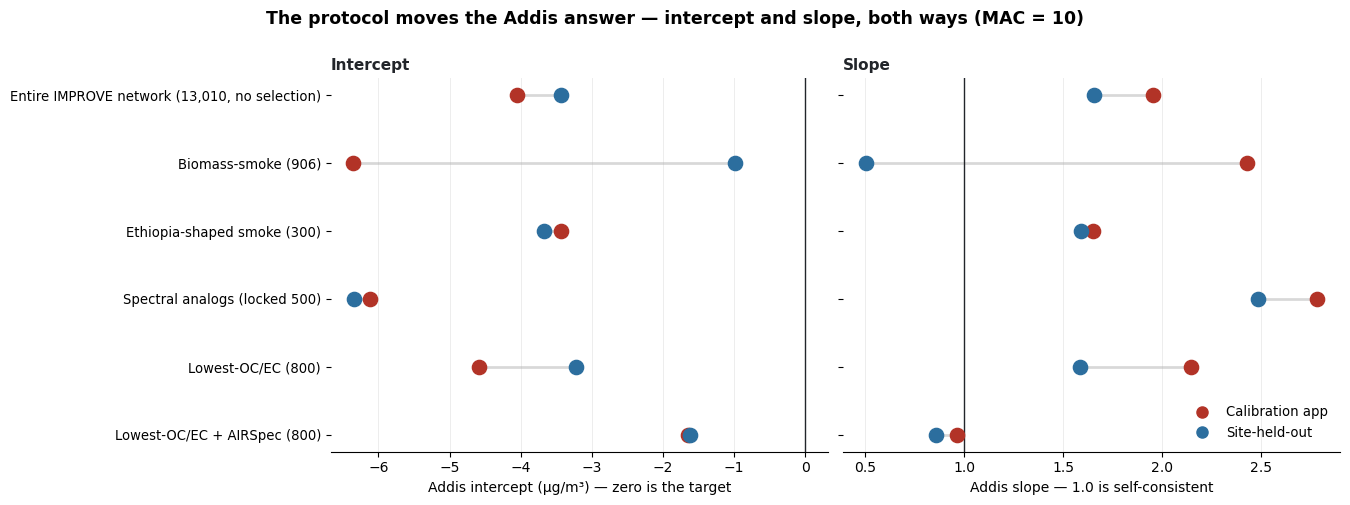

In [7]:
fig, (ax_i, ax_s) = plt.subplots(1, 2, figsize=(13.6, 5.0), sharey=True)
rows = PANELS[::-1]
for yi, name in enumerate(rows):
    for mode in MODES:
        row = metrics[(metrics['cohort'] == name.replace('\n', ' '))
                      & (metrics['mode'] == mode) & (metrics['MAC_m2_g'] == 10)
                      & (metrics['evaluation_set'] == 'fixed phase-2 cohort')].iloc[0]
        for ax, value in ((ax_i, row['intercept']), (ax_s, row['slope'])):
            ax.scatter([value], [yi], s=105, color=MODE_COLOUR[mode], zorder=3)
    pair_i = [metrics[(metrics['cohort'] == name.replace('\n', ' '))
                      & (metrics['mode'] == m) & (metrics['MAC_m2_g'] == 10)
                      & (metrics['evaluation_set'] == 'fixed phase-2 cohort')].iloc[0]
              for m in MODES]
    ax_i.plot([pair_i[0]['intercept'], pair_i[1]['intercept']], [yi, yi],
              color='0.7', lw=2, alpha=.5, zorder=2)
    ax_s.plot([pair_i[0]['slope'], pair_i[1]['slope']], [yi, yi],
              color='0.7', lw=2, alpha=.5, zorder=2)
ax_i.axvline(0, color=INK, lw=1)
ax_s.axvline(1, color=INK, lw=1)
ax_i.set_yticks(range(len(rows)))
ax_i.set_yticklabels([n.replace('\n', ' ') for n in rows], fontsize=9.5)
ax_i.set_xlabel('Addis intercept (µg/m³) — zero is the target')
ax_s.set_xlabel('Addis slope — 1.0 is self-consistent')
ax_i.set_title('Intercept', fontsize=11, fontweight='bold', color=INK, loc='left')
ax_s.set_title('Slope', fontsize=11, fontweight='bold', color=INK, loc='left')
for ax in (ax_i, ax_s):
    ax.grid(axis='x', color='0.93', lw=.7)
    ax.set_axisbelow(True)
    for spine in ('top', 'right', 'left'):
        ax.spines[spine].set_visible(False)
ax_s.legend(handles=[
    Line2D([], [], color=APP_COLOUR, marker='o', ls='', markersize=8, label='Calibration app'),
    Line2D([], [], color=HELDOUT_COLOUR, marker='o', ls='', markersize=8, label='Site-held-out'),
], loc='lower right', frameon=False, fontsize=9.5)
fig.suptitle('The protocol moves the Addis answer — intercept and slope, both ways '
             '(MAC = 10)', y=1.0, fontsize=12.5, fontweight='bold')
fig.tight_layout()
for target in (PLOT_DIR / 'intercept_slope_by_mode.png',
               DECK_DIR / 'intercept_slope_by_mode.png'):
    fig.savefig(target, dpi=190, bbox_inches='tight', facecolor='white')
plt.show()

### 6. MAC = 6 and the held-out TOR test

The MAC = 6 rows are the same fits re-expressed (ftir_19: intercept and R² are
MAC-invariant, the slope scales by 0.6). The held-out TOR test is reported where it
exists — only the site-held-out protocol produces one, which is itself the point.

In [8]:
mac6 = (metrics[(metrics['MAC_m2_g'] == 6)
                & (metrics['evaluation_set'] == 'fixed phase-2 cohort')]
        .pivot(index='cohort', columns='mode', values=['slope', 'intercept'])
        .reindex([n.replace('\n', ' ') for n in cohort_ids]))
display(mac6.round(2))
display(summary[['cohort', 'mode', 'k', 'n_train', 'pct_rmsecv_floor',
                 'heldout_TOR_R2', 'heldout_TOR_slope']].round(3))

slope              intercept  \
mode                                            app site_heldout       app   
cohort                                                                       
Entire IMPROVE network (13,010, no selection)  1.17         0.99     -4.05   
Biomass-smoke (906)                            1.46         0.30     -6.35   
Ethiopia-shaped smoke (300)                    0.99         0.95     -3.44   
Spectral analogs (locked 500)                  1.67         1.49     -6.12   
Lowest-OC/EC (800)                             1.29         0.95     -4.59   
Lowest-OC/EC + AIRSpec (800)                   0.58         0.51     -1.65   

                                                            
mode                                          site_heldout  
cohort                                                      
Entire IMPROVE network (13,010, no selection)        -3.44  
Biomass-smoke (906)                                  -0.99  
Ethiopia-shaped smoke (300)                          -3.67  
Spectral analogs (locked 500)                        -6.35  
Lowest-OC/EC (800)                                   -3.22  
Lowest-OC/EC + AIRSpec (800)                         -1.62

,cohort,mode,k,n_train,pct_rmsecv_floor,heldout_TOR_R2,heldout_TOR_slope
0,"Entire IMPROVE network (13,010, no selection)",app,27,13010,104.689,NaN,NaN
1,"Entire IMPROVE network (13,010, no selection)",site_heldout,15,10740,135.400,0.695,0.988
2,Biomass-smoke (906),app,19,906,101.133,NaN,NaN
3,Biomass-smoke (906),site_heldout,4,708,106.563,0.543,0.734
4,Ethiopia-shaped smoke (300),app,17,300,39.332,NaN,NaN
5,Ethiopia-shaped smoke (300),site_heldout,10,256,39.427,0.004,-2.199
6,Spectral analogs (locked 500),app,9,500,62.088,NaN,NaN
7,Spectral analogs (locked 500),site_heldout,4,372,67.075,0.367,0.619
8,Lowest-OC/EC (800),app,17,800,62.477,NaN,NaN
9,Lowest-OC/EC (800),site_heldout,6,606,72.161,0.911,0.875


## Takeaways

- **Report the protocol with the number.** "Intercept −3.22" and "intercept −4.59" are the
  same cohort, the same filters and the same maths; only the component-selection protocol
  differs. Any cross-project comparison of Addis intercepts that doesn't state the protocol
  is comparing two things at once.
- **The protocol is a bigger lever than the MAC fork.** ftir_19 showed MAC cannot move an
  intercept at all (it rescales x, so each calibration pivots on its own intercept). The
  protocol moves the lowest-OC/EC intercept by 1.4 µg/m³ — so of the two open arguments,
  this is the one that changes the headline number.
- **Lowest-OC/EC + AIRSpec is protocol-robust**, landing at −1.65 / −1.62 either way. Taken
  with ftir_20's result that the same cohort is indifferent to the CV fold structure
  (optimism ×1.01), this is the strongest argument the deck has: its answer does not depend
  on analyst choices.
- **Ethiopia-shaped smoke should be retired from the matrix, or asterisked.** Under a
  site-disjoint test it has R² 0.00 and slope −2.20 — no held-out skill. It joins the
  spectral analogs as a setup whose attractive Addis intercept is not backed by a TOR test.
- **Two confounds are inherent to an end-to-end protocol comparison, not bugs**: the app
  mode fits on the whole cohort (e.g. 800 filters) while the site-held-out mode fits on the
  training part (606), so training size travels with the protocol; and the app mode produces no
  site-disjoint test by construction, which is why that column is blank rather than filled
  with an in-sample number.
- **Caveat**: the Calibration app protocol is applied here to *each of these cohorts*,
  which is not literally what the app ships — it trains on 21 hardcoded IMPROVE sites plus the
  BiomassDetected lists. This isolates the protocol while holding the cohort fixed, which
  is the comparison that answers "what does the protocol cost", not "what exactly is
  deployed".